In [1]:
import shap
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import joblib
import numpy as np
import re
from IPython.display import display, HTML

from scipy.stats import mode

In [2]:
predictions = pd.read_parquet('predictions_with_timestamps.parquet', engine='pyarrow')
predictions.head()

IOStream.flush timed out


,id,clean_text,text,timestamp,party,sentiment
0,1844361929781113331,many failure bidens administration directly tr...,@a_newsman Many failures of Bidens administrat...,2024-10-10,democrat,negative
1,1844361929550332320,lie biden told american misinformation set exa...,@atensnut The lies Biden told Americans about ...,2024-10-10,democrat,negative
2,1844361928925384711,someone talented fundraising team,@TheDemocrats here’s someone very talented for...,2024-10-10,democrat,positive
3,1844361928585654516,chipper usd card working expressionless face,@LifeOfNapaul Chipper USD card isn’t working 😑,2024-10-10,democrat,negative
4,1844361927495123076,yes n't done live interview real journalist si...,@MTGrepp Yes. She hasn't done a live interview...,2024-10-10,democrat,positive


In [3]:
train = pd.read_parquet('train_labelled.parquet', engine='pyarrow')
train.head()

,clean_text,party,sentiment,timestamp
0,maga maha trumpvance2024 trump2024 magamovemen...,republican,positive,2024-10-10
1,favorite post kamala harris pretending like de...,democrat,positive,2024-10-10
2,ron desantis signed sb304 price gouging back a...,democrat,positive,2024-10-10
3,200 people dead hurricane 99 republican voted ...,republican,negative,2024-10-10
4,wtaf coward afraid 60 minute 're incapable tel...,republican,negative,2024-10-10


## Party Classifier

In [4]:
X_train, y_train = train['clean_text'], train['party']
X_test, y_test = predictions['clean_text'], predictions['party']

SAMPLE_SIZE = min(50000, len(X_test)/100)
print(SAMPLE_SIZE)
TOTAL_RECORDS = len(X_test)
print(TOTAL_RECORDS)
test_ratio = SAMPLE_SIZE / TOTAL_RECORDS
print(test_ratio)

if test_ratio < 1.0:
    _, sample_indices, _, _ = train_test_split(
        y_test.index,+
        y_test,
        test_size=test_ratio,
        stratify=y_test,
        random_state=42
    )

    X_sample_test = X_test.loc[sample_indices]
    y_sample_test = y_test.loc[sample_indices]
else:
    X_sample_test = X_test
    y_sample_test = y_test

50000
36029216
0.0013877626424066514


In [5]:
print(len(X_sample_test))
print(len(y_sample_test))

50000
50000


In [6]:
party_model = joblib.load("models/LightGBM_party_classifier.joblib")
tfidf = party_model.named_steps["tfidf"]
lgb_model = party_model.named_steps["clf"]

X_sample_test_tfidf = tfidf.transform(X_sample_test)

In [7]:
print("TF-IDF shape:", X_sample_test_tfidf.shape)
print("Number of features:", len(tfidf.get_feature_names_out()))

TF-IDF shape: (50000, 20000)
Number of features: 20000


In [8]:
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer(X_sample_test_tfidf)

In [9]:
print(type(shap_values.values), shap_values.values.shape)


<class 'scipy.sparse._csr.csr_matrix'> (50000, 20000)


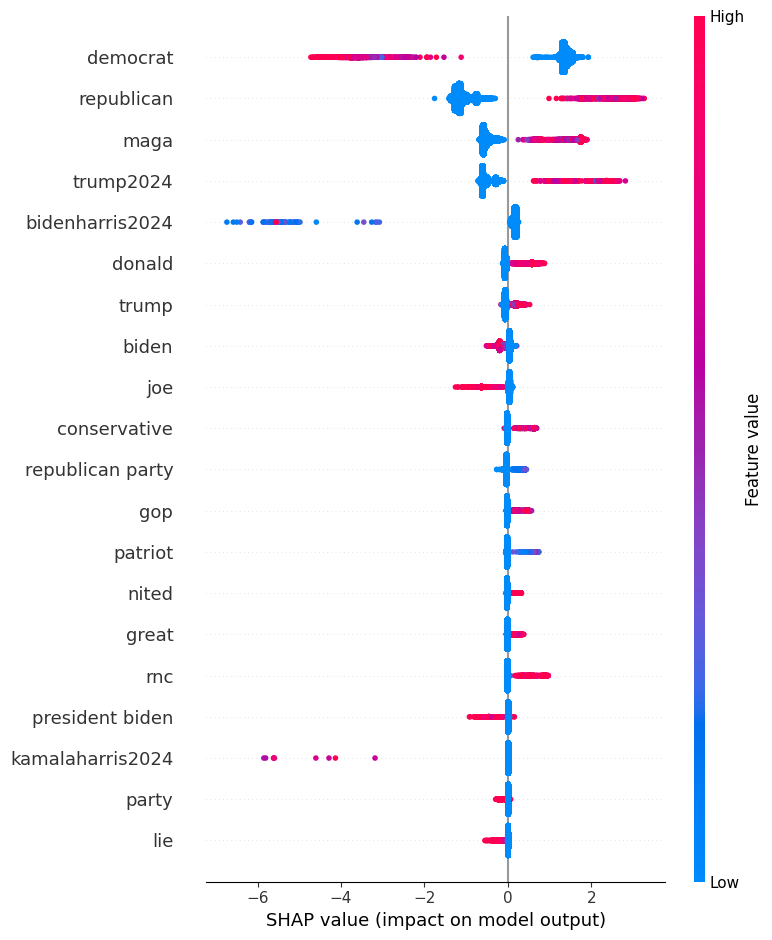

In [10]:
feature_names = tfidf.get_feature_names_out()

shap_dense = shap_values.values.toarray()  # shape: (10000, 20000)
X_dense = X_sample_test_tfidf.toarray()

shap.initjs()

shap.summary_plot(shap_dense, features=X_dense, feature_names=feature_names)


In [11]:
max_abs_shap = np.abs(shap_dense).max(axis=1) 

df_pred = pd.DataFrame({
    'predicted_party': y_sample_test.values,
    'max_abs_shap': max_abs_shap
})

dem_pred = df_pred[df_pred.predicted_party == 'democrat']
rep_pred = df_pred[df_pred.predicted_party == 'republican']

print("Democrat predictions SHAP stats:")
dem_pred['max_abs_shap'].describe()



Democrat predictions SHAP stats:


count    36900.000000
mean         1.497697
std          0.572180
min          1.106524
25%          1.342150
50%          1.358861
75%          1.396136
max          6.734604
Name: max_abs_shap, dtype: float64

In [12]:
print("\nRepublican predictions SHAP stats:")
rep_pred['max_abs_shap'].describe()


Republican predictions SHAP stats:


count    13100.000000
mean         1.705365
std          0.361811
min          1.290856
25%          1.503260
50%          1.557100
75%          1.747801
max          3.595276
Name: max_abs_shap, dtype: float64

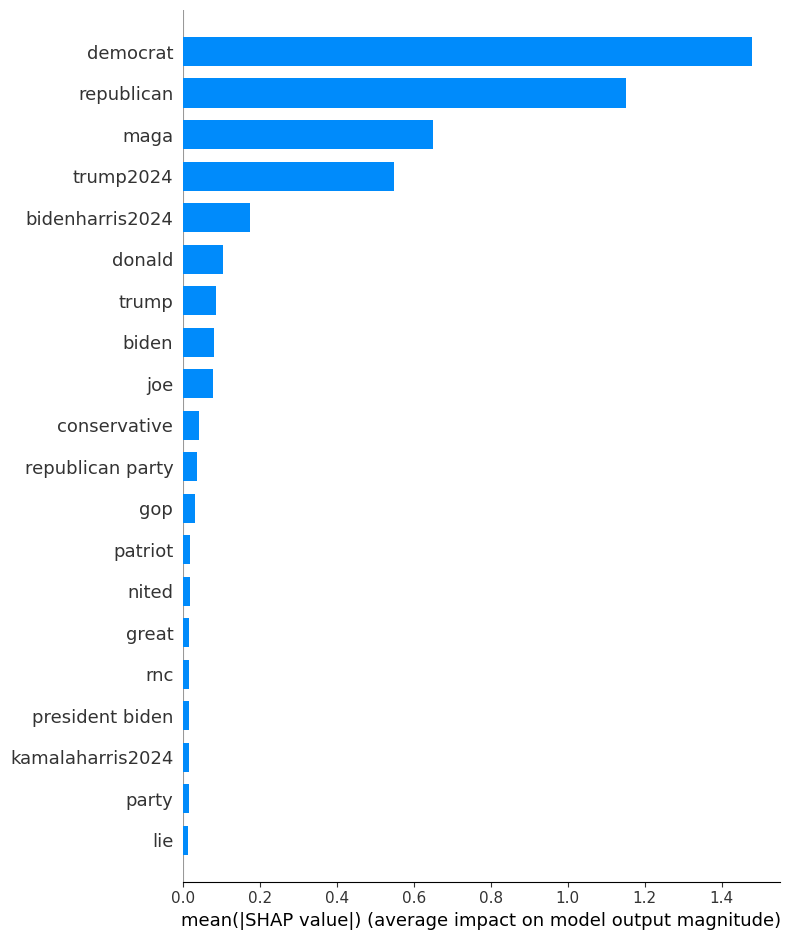

In [13]:
# Mean absolute SHAP values per feature
mean_abs_shap = np.abs(shap_dense).mean(axis=0)

# Top 50 features
top_idx = np.argsort(mean_abs_shap)[-50:]
feature_names_top = feature_names[top_idx]
shap_top = shap_dense[:, top_idx]
X_top = X_dense[:, top_idx]

# Global feature importance bar plot
shap.summary_plot(shap_top, features=X_top, feature_names=feature_names_top, plot_type="bar")


In [14]:
# Check class encoding
print("Class labels:", lgb_model.classes_)
print("Positive class (index 1):", lgb_model.classes_[1])
print("Negative class (index 0):", lgb_model.classes_[0])


Class labels: ['democrat' 'republican']
Positive class (index 1): republican
Negative class (index 0): democrat


In [15]:
feature_importance = []

for i, feature_name in enumerate(feature_names):
    feature_vals = X_dense[:, i]
    shap_vals = shap_dense[:, i]
    
    # Only consider samples where feature is present
    mask = feature_vals > 0
    if mask.sum() > 0:
        mean_shap_when_present = shap_vals[mask].mean()
        feature_importance.append({
            'Feature': feature_name,
            'Active SHAP': mean_shap_when_present,
            'Active Occurences': mask.sum(),
            'Direction': 'republican' if mean_shap_when_present > 0 else 'democrat'
        })

df = pd.DataFrame(feature_importance).sort_values(
    by='Active SHAP', 
    ascending=False
)


In [16]:
print("Directional Importance (top 10 pushing toward REPUBLICAN):")
df.head(10)

Directional Importance (top 10 pushing toward REPUBLICAN):


,Feature,Active SHAP,Active Occurences,Direction
13515,republican,2.562421,1542,republican
16991,trump2024,2.061605,856,republican
17709,voteouteveryrepublican,1.804606,2,republican
13715,republicanism,1.620107,2,republican
9935,maga,1.559488,5754,republican
14749,single democrat,1.532128,3,republican
10099,magacultmorons,1.507718,7,republican
4338,democrat administration,1.448224,3,republican
5649,every democrat,1.425582,8,republican
1081,another democrat,1.417318,11,republican


In [17]:
print("Directional Importance (top 10 pushing toward DEMOCRAT):")
df.tail(10)

Directional Importance (top 10 pushing toward DEMOCRAT):


,Feature,Active SHAP,Active Occurences,Direction
13394,registerdemocrats,-1.198426,1,democrat
14034,rt breaking,-1.244694,16,democrat
4648,democratslie,-1.390854,1,democrat
4646,democratsdividinganddestroyingamerica,-1.688818,1,democrat
16011,thedemocrats,-1.760227,1,democrat
4647,democratshateamerica,-2.842954,1,democrat
4645,democratsaredestroyingamerica,-3.629448,3,democrat
4331,democrat,-3.649467,1928,democrat
8805,kamalaharris2024,-4.964823,9,democrat
2222,bidenharris2024,-5.422116,132,democrat


In [18]:
print(type(X_dense))
print(X_dense.shape)
print(f"Array size: {X_dense.nbytes / 1e9:.2f} GB")

print(type(shap_dense))
print(shap_dense.shape)


<class 'numpy.ndarray'>
(50000, 20000)
Array size: 8.00 GB
<class 'numpy.ndarray'>
(50000, 20000)


In [19]:
mean_abs_shap = np.abs(shap_dense).mean(axis=0)
non_zero_mask = mean_abs_shap > 0
non_zero_indices = np.where(non_zero_mask)[0]
top_features_idx = non_zero_indices[np.argsort(mean_abs_shap[non_zero_indices])[::-1]]

results = []
for feat_idx in top_features_idx:
    feature_vals = X_dense[:, feat_idx]
    feature_shaps = shap_dense[:, feat_idx]
    
    baseline_mask = feature_vals == 0
    active_mask = feature_vals > 0
    
    baseline_shap = feature_shaps[baseline_mask].mean() if baseline_mask.sum() > 0 else 0
    active_shap = feature_shaps[active_mask].mean() if active_mask.sum() > 0 else 0
    
    results.append({
        'Feature': feature_names[feat_idx],
        'Total_Occurrences': len(feature_vals),
        'Active_Occurrences': active_mask.sum(),
        'Density': round(active_mask.sum() / len(feature_vals), 3),
        'Sparsity': round(1 - active_mask.sum() / len(feature_vals), 3),
        'Mean_Abs_SHAP': round(mean_abs_shap[feat_idx], 4),
        'Mean_Raw_SHAP': round(feature_shaps.mean(), 4),
        'Baseline_SHAP': round(baseline_shap, 4),
        'Active_SHAP': round(active_shap, 4),
        'Active_Minus_Baseline': round(active_shap - baseline_shap, 4),
        'Std_SHAP': round(feature_shaps.std(), 4),
        'Max_SHAP': round(feature_shaps.max(), 4),
        'Min_SHAP': round(feature_shaps.min(), 4),
    })

party_shap = pd.DataFrame(results)

In [20]:
party_shap = party_shap.sort_values(
    by='Mean_Abs_SHAP', 
    ascending=False)
party_shap.head(20)

,Feature,Total_Occurrences,Active_Occurrences,Density,Sparsity,Mean_Abs_SHAP,Mean_Raw_SHAP,Baseline_SHAP,Active_SHAP,Active_Minus_Baseline,Std_SHAP,Max_SHAP,Min_SHAP
0,democrat,50000,1928,0.039,0.961,1.4782,1.1967,1.3911,-3.6495,-5.0405,0.9771,1.9293,-4.7220
1,republican,50000,1542,0.031,0.969,1.1527,-0.9947,-1.1079,2.5624,3.6703,0.6623,3.2713,-1.7562
2,maga,50000,5754,0.115,0.885,0.6498,-0.2909,-0.5315,1.5595,2.0910,0.6802,1.9012,-0.6907
3,trump2024,50000,856,0.017,0.983,0.5476,-0.4770,-0.5212,2.0616,2.5828,0.3622,2.8176,-0.7143
4,bidenharris2024,50000,132,0.003,0.997,0.1744,0.1457,0.1605,-5.4221,-5.5826,0.2893,0.2601,-6.7346
5,donald,50000,4365,0.087,0.913,0.1028,-0.0113,-0.0625,0.5239,0.5864,0.1704,0.8803,-0.1245
6,trump,50000,11988,0.240,0.760,0.0866,-0.0077,-0.0618,0.1638,0.2257,0.1054,0.5239,-0.1659
7,biden,50000,21095,0.422,0.578,0.0815,-0.0267,0.0452,-0.1252,-0.1704,0.1002,0.2122,-0.5159
8,joe,50000,3776,0.076,0.924,0.0784,-0.0017,0.0415,-0.5306,-0.5721,0.1568,0.1207,-1.2558
9,conservative,50000,2366,0.047,0.953,0.0403,0.0127,-0.0144,0.5600,0.5745,0.1253,0.6923,-0.0884


In [21]:
shap_raw_dense = shap_dense 
abs_shap_dense = np.abs(shap_dense)
max_shap_per_instance = np.abs(shap_dense).max(axis=1)
high_leverage_mask = max_shap_per_instance > 2.0
dominant_feature_indices = np.argmax(abs_shap_dense, axis=1)
high_leverage_indices = dominant_feature_indices[high_leverage_mask]
unique_indices, counts = np.unique(high_leverage_indices, return_counts=True)
distinct_high_leverage_terms = feature_names[unique_indices]

mean_raw_direction = []
peak_shap_values = []  
lowest_shap_values = []  
range_shap_values = []
prediction_mode = []

for j in unique_indices:
    instance_mask = high_leverage_mask & (dominant_feature_indices == j)
    
    # Calculate SHAP statistics
    mean_raw = np.mean(shap_raw_dense[instance_mask, j])
    mean_raw_direction.append(mean_raw)
    
    max_shap = np.max(shap_raw_dense[instance_mask, j])
    min_shap = np.min(shap_raw_dense[instance_mask, j])
    
    # Peak = value with highest absolute magnitude (most extreme)
    if abs(min_shap) > abs(max_shap):
        peak_shap = min_shap
        lowest_shap = max_shap 
    else:
        peak_shap = max_shap
        lowest_shap = min_shap 
    
    peak_shap_values.append(peak_shap)
    lowest_shap_values.append(lowest_shap)
    
    # Range
    range_shap = max_shap - min_shap
    range_shap_values.append(range_shap)
    
    predictions_for_feature = y_sample_test[instance_mask]
    most_common_pred = pd.Series(predictions_for_feature).mode()[0]
    prediction_mode.append(most_common_pred)
    
high_leverage_df = pd.DataFrame({
    'Feature': distinct_high_leverage_terms,
    'Count': counts,
    'Mean_When_Dominant': mean_raw_direction,
    'Peak_When_Dominant': peak_shap_values,
    'Lowest_When_Dominant': lowest_shap_values,
    'Range_When_Dominant': range_shap_values,
    'Predicted_Class': prediction_mode
})

high_leverage_df = high_leverage_df.sort_values(by=['Count'], ascending=False)
high_leverage_df

,Feature,Count,Mean_When_Dominant,Peak_When_Dominant,Lowest_When_Dominant,Range_When_Dominant,Predicted_Class
1,democrat,1916,-3.659092,-4.722005,-2.196370,2.525634,democrat
8,republican,1074,2.706816,3.246934,2.005388,1.241546,republican
10,trump2024,594,2.307326,2.597254,2.001175,0.596079,republican
0,bidenharris2024,132,-5.422116,-6.734604,-3.078595,3.656009,democrat
4,kamalaharris2024,9,-4.964823,-5.849699,-3.183425,2.666273,democrat
5,maga2024,9,2.058957,2.086546,2.005171,0.081375,republican
2,democratsaredestroyingamerica,3,-3.629448,-4.374689,-2.230254,2.144435,democrat
3,democratshateamerica,1,-2.842954,-2.842954,-2.842954,0.000000,democrat
6,magacult,1,2.104660,2.104660,2.104660,0.000000,republican
7,magacultmorons,1,2.352086,2.352086,2.352086,0.000000,republican


In [22]:
print(sum(high_leverage_df['Count']))
print((high_leverage_df['Feature']).nunique())

3741
11


## Democrat Sentiment Classifier

50000
26589241
0.1880459844641673


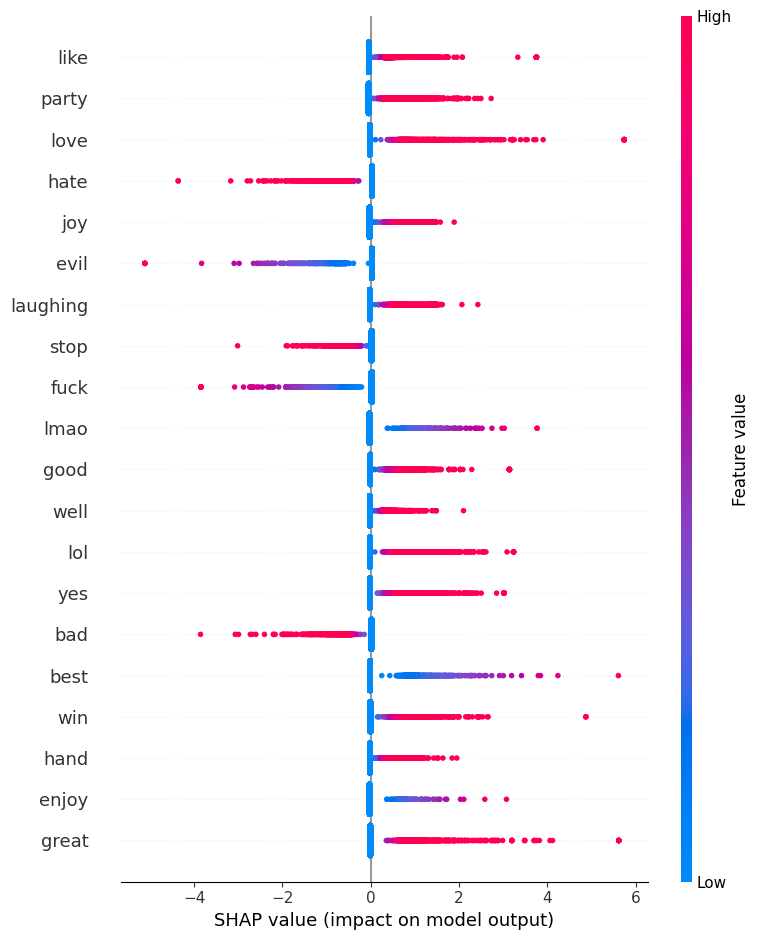

In [23]:
model = joblib.load("models/LinearSVC_democrat_sentiment_classifier.joblib")
tfidf = model.named_steps['tfidf']
clf = model.named_steps['clf']

democrat_train = train[train['party'] == 'democrat'].copy()
democrat_predict = predictions[predictions['party'] == 'democrat'].copy()

X_train, y_train = democrat_train['clean_text'], democrat_train['sentiment']
X_test, y_test = democrat_predict['clean_text'], democrat_predict['sentiment']

SAMPLE_SIZE = min(50000, len(X_test)/100)
print(SAMPLE_SIZE)
TOTAL_RECORDS = len(X_test)
print(TOTAL_RECORDS)
test_ratio = SAMPLE_SIZE / TOTAL_RECORDS
print(test_ratio * 100)

if test_ratio < 1.0:
    _, sample_indices, _, _ = train_test_split(
        y_test.index,
        y_test,
        test_size=test_ratio,
        stratify=y_test,
        random_state=42
    )

    X_sample_test = X_test.loc[sample_indices]
    y_sample_test = y_test.loc[sample_indices]
else:
    X_sample_test = X_test
    y_sample_test = y_test

democrat_tfidf = tfidf.transform(X_sample_test)
democrat_tfidf_dense = democrat_tfidf.toarray()

explainer = shap.LinearExplainer(clf, democrat_tfidf_dense)
shap_values = explainer.shap_values(democrat_tfidf_dense)

dem_feature_names = tfidf.get_feature_names_out()

shap.summary_plot(
    shap_values, 
    democrat_tfidf_dense, 
    feature_names=dem_feature_names,
    title="SHAP Summary: Democratic Sentiment Classification"
)

In [24]:
class_labels = clf.classes_
print(class_labels)

['negative' 'positive']


In [25]:
type(shap_values)
shap_dense = shap_values

In [26]:
print(type(democrat_tfidf_dense))
print(democrat_tfidf_dense.shape)
print(f"Array size: {democrat_tfidf_dense.nbytes / 1e9:.2f} GB")

print(type(shap_dense))
print(shap_dense.shape)


<class 'numpy.ndarray'>
(50000, 10000)
Array size: 4.00 GB
<class 'numpy.ndarray'>
(50000, 10000)


In [27]:
feature_importance = []

for i, feature_name in enumerate(dem_feature_names):
    feature_vals = democrat_tfidf_dense[:, i]
    shap_vals = shap_dense[:, i]
    
    # Only consider samples where feature is present
    mask = feature_vals > 0
    if mask.sum() > 0:
        mean_shap_when_present = shap_vals[mask].mean()
        feature_importance.append({
            'Feature': feature_name,
            'Active_SHAP': mean_shap_when_present,
            'Count_Present': mask.sum(),
            'Direction': 'positive' if mean_shap_when_present > 0 else 'negative'
        })

dem_df = pd.DataFrame(feature_importance).sort_values(
    by='Active_SHAP', 
    ascending=False
)


In [28]:
print("Directional Importance (top 10 pushing toward negative sentiment):")
dem_df.head(10)

Directional Importance (top 10 pushing toward negative sentiment):


,Feature,Active_SHAP,Count_Present,Direction
1443,brilliant,1.625312,29,positive
5372,love,1.379910,618,positive
5300,lmao,1.308650,125,positive
4036,great,1.288180,581,positive
1935,congratulation,1.267250,29,positive
752,awesome,1.260682,52,positive
6456,perfectly,1.248819,37,positive
855,beautiful,1.209250,54,positive
4117,hahaha,1.208137,24,positive
905,best,1.196568,495,positive


In [29]:
print("Directional Importance (top 10 pushing toward negative sentiment):")
dem_df.tail(10)

Directional Importance (top 10 pushing toward negative sentiment):


,Feature,Active_SHAP,Count_Present,Direction
1562,cancer,-1.157213,38,negative
6346,pathetic,-1.184363,154,negative
4277,hated,-1.197707,46,negative
9651,wtf,-1.212296,108,negative
7778,slavery,-1.230240,38,negative
1521,ca win,-1.250603,18,negative
6513,pissed,-1.258215,66,negative
3744,fucked,-1.300660,69,negative
5965,never win,-1.352721,9,negative
4342,hell,-1.598962,328,negative


In [30]:
max_abs_shap = np.abs(shap_dense).max(axis=1) 

df_pred = pd.DataFrame({
    'predicted_party': y_sample_test.values,
    'max_abs_shap': max_abs_shap
})

pos_pred = df_pred[df_pred.predicted_party == 'positive']
neg_pred = df_pred[df_pred.predicted_party == 'negative']

print("Democrat predictions SHAP stats:")
pos_pred['max_abs_shap'].describe()


Democrat predictions SHAP stats:


count    21662.000000
mean         0.778975
std          0.537190
min          0.045798
25%          0.452564
50%          0.671342
75%          0.982331
max          5.743328
Name: max_abs_shap, dtype: float64

In [31]:
neg_pred['max_abs_shap'].describe()

count    28338.000000
mean         0.661905
std          0.529050
min          0.045798
25%          0.249729
50%          0.592990
75%          0.884535
max          6.349633
Name: max_abs_shap, dtype: float64

In [32]:
print(np.shape(shap_values))


(50000, 10000)


In [33]:
mean_abs_shap = np.abs(shap_dense).mean(axis=0)
non_zero_mask = mean_abs_shap > 0
non_zero_indices = np.where(non_zero_mask)[0]
top_features_idx = non_zero_indices[np.argsort(mean_abs_shap[non_zero_indices])[::-1]]

results = []
for feat_idx in top_features_idx:
    feature_vals = democrat_tfidf_dense[:, feat_idx]
    feature_shaps = shap_dense[:, feat_idx]
    
    baseline_mask = feature_vals == 0
    active_mask = feature_vals > 0
    
    baseline_shap = feature_shaps[baseline_mask].mean() if baseline_mask.sum() > 0 else 0
    active_shap = feature_shaps[active_mask].mean() if active_mask.sum() > 0 else 0
    
    results.append({
        'Feature': dem_feature_names[feat_idx],
        'Active_Occurrences': active_mask.sum(),
        'Density': round((active_mask.sum() / len(feature_vals)), 3) * 100,
        'Sparsity': round(1 - active_mask.sum() / len(feature_vals), 3) * 100,
        'Baseline_SHAP': round(baseline_shap, 4),
        'Active_SHAP': round(active_shap, 4),
        'Active_Minus_Baseline': round(active_shap - baseline_shap, 4),
        'Mean_Raw_SHAP': round(feature_shaps.mean(), 4),
        'Mean_Abs_SHAP': round(mean_abs_shap[feat_idx], 4),
        'Std_SHAP': round(feature_shaps.std(), 4),
         # max and min include non-active occurences         
        'Max_SHAP': round(feature_shaps.max(), 4), 
        'Min_SHAP': round(feature_shaps.min(), 4),
    })

dem_shap = pd.DataFrame(results)
dem_shap = dem_shap.sort_values(by=['Mean_Abs_SHAP'], ascending=False)
dem_shap.head(10)

,Feature,Active_Occurrences,Density,Sparsity,Baseline_SHAP,Active_SHAP,Active_Minus_Baseline,Mean_Raw_SHAP,Mean_Abs_SHAP,Std_SHAP,Max_SHAP,Min_SHAP
0,like,3568,7.1,92.9,-0.0426,0.5657,0.6082,0.0008,0.0799,0.1795,3.7540,-0.0426
1,party,2552,5.1,94.9,-0.0458,0.6587,0.7045,-0.0098,0.0771,0.1713,2.7289,-0.0458
2,love,618,1.2,98.8,-0.0204,1.3799,1.4003,-0.0030,0.0372,0.1904,5.7433,-0.0204
3,hate,561,1.1,98.9,0.0275,-0.8585,-0.8859,0.0175,0.0368,0.1053,0.0275,-4.3605
4,joy,674,1.3,98.7,-0.0243,0.8542,0.8785,-0.0124,0.0355,0.1088,1.8916,-0.0243
5,evil,307,0.6,99.4,0.0269,-1.1548,-1.1817,0.0197,0.0338,0.1103,0.0269,-5.1156
6,laughing,589,1.2,98.8,-0.0195,0.9463,0.9658,-0.0081,0.0304,0.1119,2.4274,-0.0195
7,stop,951,1.9,98.1,0.0207,-0.5236,-0.5443,0.0103,0.0303,0.0820,0.0207,-3.0139
8,fuck,352,0.7,99.3,0.0223,-1.1071,-1.1294,0.0144,0.0300,0.1129,0.0223,-3.8483
9,lmao,125,0.2,99.8,-0.0261,1.3086,1.3347,-0.0227,0.0293,0.0735,3.7685,-0.0261


In [34]:
shap_raw_dense = shap_dense 
abs_shap_dense = np.abs(shap_dense)
max_shap_per_instance = np.abs(shap_dense).max(axis=1)
high_leverage_mask = max_shap_per_instance > 2.0
dominant_feature_indices = np.argmax(abs_shap_dense, axis=1)
high_leverage_indices = dominant_feature_indices[high_leverage_mask]
unique_indices, counts = np.unique(high_leverage_indices, return_counts=True)
distinct_high_leverage_terms = dem_feature_names[unique_indices]

mean_raw_direction = []
peak_shap_values = []  
lowest_shap_values = []  
range_shap_values = []
prediction_mode = []

for j in unique_indices:
    instance_mask = high_leverage_mask & (dominant_feature_indices == j)
    
    # Calculate SHAP statistics
    mean_raw = np.mean(shap_raw_dense[instance_mask, j])
    mean_raw_direction.append(mean_raw)
    
    max_shap = np.max(shap_raw_dense[instance_mask, j])
    min_shap = np.min(shap_raw_dense[instance_mask, j])
    
    # Peak = value with highest absolute magnitude (most extreme)
    peak_shap = max_shap if abs(max_shap) > abs(min_shap) else min_shap
    # Least extreme (closest to 0)
    lowest_shap = min_shap if abs(max_shap) > abs(min_shap) else max_shap
    
    peak_shap_values.append(peak_shap)
    lowest_shap_values.append(lowest_shap)
    
    # Range
    range_shap = max_shap - min_shap
    range_shap_values.append(range_shap)
    
    predictions_for_feature = y_sample_test[instance_mask]
    most_common_pred = pd.Series(predictions_for_feature).mode()[0]
    prediction_mode.append(most_common_pred)
    
high_leverage_df = pd.DataFrame({
    'Feature': distinct_high_leverage_terms,
    'Count': counts,
    'Mean_When_Dominant': mean_raw_direction,
    'Peak_When_Dominant': peak_shap_values,
    'Lowest_When_Dominant': lowest_shap_values,
    'Range_When_Dominant': range_shap_values,
    'Predicted_Class': prediction_mode
})

high_leverage_df = high_leverage_df.sort_values(by=['Count'], ascending=False)
high_leverage_df.head(10)

,Feature,Count,Mean_When_Dominant,Peak_When_Dominant,Lowest_When_Dominant,Range_When_Dominant,Predicted_Class
122,love,90,3.287853,5.743328,2.007874,3.735454,positive
82,great,58,3.227213,5.620842,2.016195,3.604647,positive
92,hell,57,-3.504199,-6.349633,-2.014910,4.334723,negative
208,yes,42,2.610820,3.018012,2.002947,1.015065,positive
91,heart,38,2.294533,4.723418,2.005035,2.718384,positive
13,best,31,2.676284,5.611424,2.002473,3.608950,positive
75,fuck,30,-3.066025,-3.848316,-2.083523,1.764794,negative
118,lol,29,2.569531,3.236703,2.005198,1.231506,positive
56,evil,28,-3.030200,-5.115554,-2.032633,3.082922,negative
119,loser,26,-2.723211,-3.517105,-2.036459,1.480646,negative


In [35]:
print(sum(high_leverage_df['Count']))
print((high_leverage_df['Feature']).nunique())

frequent_features = high_leverage_df[high_leverage_df['Count'] >= 5]
num_frequent_features = frequent_features['Feature'].nunique()
total_frequent_instances = frequent_features['Count'].sum()

print(num_frequent_features)       
print(total_frequent_instances)   

1288
209
69
1045


In [36]:
print(high_leverage_df['Predicted_Class'].unique())

['positive' 'negative']


In [37]:
pos_features = high_leverage_df[(high_leverage_df['Predicted_Class'] == 'positive') & 
                                 (high_leverage_df['Count'] >= 5)]
num_pos_featurs = pos_features['Feature'].nunique()
total_pos_features = pos_features['Count'].sum()

print(num_pos_featurs)       
print(total_pos_features)   

30
558


In [38]:
pos_features = high_leverage_df[(high_leverage_df['Predicted_Class'] == 'positive')]
num_pos_featurs = pos_features['Feature'].nunique()
total_pos_features = pos_features['Count'].sum()

print(num_pos_featurs)       
print(total_pos_features)   

80
647


In [39]:
neg_features = high_leverage_df[(high_leverage_df['Predicted_Class'] == 'negative') & 
                                 (high_leverage_df['Count'] >= 5)]
num_neg_featurs = neg_features['Feature'].nunique()
total_neg_features = neg_features['Count'].sum()

print(num_neg_featurs)       
print(total_neg_features)

39
487


In [40]:
neg_features = high_leverage_df[(high_leverage_df['Predicted_Class'] == 'negative')]
num_neg_featurs = neg_features['Feature'].nunique()
total_neg_features = neg_features['Count'].sum()

print(num_neg_featurs)       
print(total_neg_features)

129
641


## Republican Sentiment Classifier

50000
9439975
0.005296624196568317


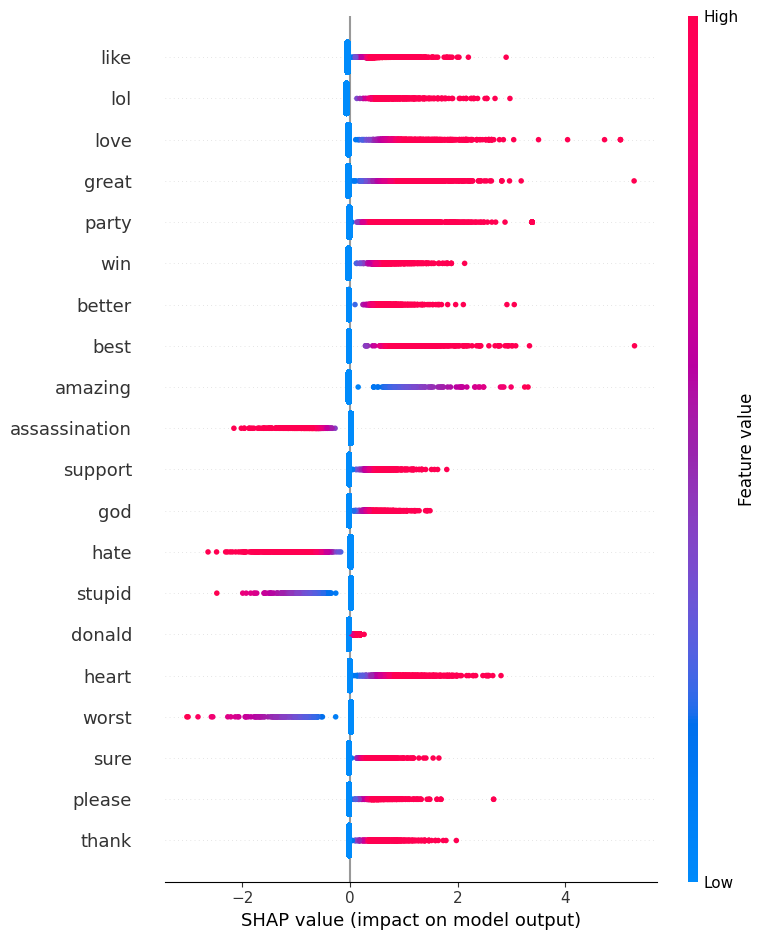

In [41]:
model = joblib.load("models/LinearSVC_republican_sentiment_classifier.joblib")
tfidf = model.named_steps['tfidf']
clf = model.named_steps['clf']

rep_train = train[train['party'] == 'republican'].copy()
rep_predict = predictions[predictions['party'] == 'republican'].copy()

X_train, y_train = rep_train['clean_text'], rep_train['sentiment']
X_test, y_test = rep_predict['clean_text'], rep_predict['sentiment']

SAMPLE_SIZE = min(50000, len(X_test)/100)
print(SAMPLE_SIZE)
TOTAL_RECORDS = len(X_test)
print(TOTAL_RECORDS)
test_ratio = SAMPLE_SIZE / TOTAL_RECORDS
print(test_ratio)

if test_ratio < 1.0:
    _, sample_indices, _, _ = train_test_split(
        y_test.index,
        y_test,
        test_size=test_ratio,
        stratify=y_test,
        random_state=42
    )

    X_sample_test = X_test.loc[sample_indices]
    y_sample_test = y_test.loc[sample_indices]
else:
    X_sample_test = X_test
    y_sample_test = y_test

republican_tfidf = tfidf.transform(X_sample_test)
republican_tfidf_dense = republican_tfidf.toarray()

explainer = shap.LinearExplainer(clf, republican_tfidf_dense)
shap_values = explainer.shap_values(republican_tfidf_dense)

rep_feature_names = tfidf.get_feature_names_out()

shap.summary_plot(
    shap_values, 
    republican_tfidf_dense,
    feature_names=rep_feature_names,
    title="SHAP Summary: Republican Sentiment Classification"
)

In [42]:
feature_importance = []

for i, feature_name in enumerate(rep_feature_names):
    feature_vals = republican_tfidf_dense[:, i]
    shap_vals = shap_values[:, i]
    
    # Only consider samples where feature is present
    mask = feature_vals > 0
    if mask.sum() > 0:
        mean_shap_when_present = shap_vals[mask].mean()
        feature_importance.append({
            'Feature': feature_name,
            'Active_SHAP': mean_shap_when_present,
            'Count_Present': mask.sum(),
            'Direction': 'positive' if mean_shap_when_present > 0 else 'negative'
        })

rep_df = pd.DataFrame(feature_importance).sort_values(
    by='Active_SHAP', 
    ascending=False
)

print("Directional Importance (top 10 pushing toward positive sentiment):")
rep_df.head(10)


Directional Importance (top 10 pushing toward positive sentiment):


,Feature,Active_SHAP,Count_Present,Direction
741,bad as,1.426595,3,positive
703,awesome,1.171404,151,positive
345,amazing,1.171122,166,positive
867,best,1.121482,547,positive
1696,congratulation,1.099083,96,positive
3586,hahaha,1.090563,30,positive
811,beautiful,1.070902,173,positive
3519,greatest,1.065294,115,positive
4787,love,1.063314,1162,positive
9600,wow,1.043530,181,positive


In [43]:
print("Directional Importance (top 10 pushing toward negative sentiment):")
rep_df.tail(10)

Directional Importance (top 10 pushing toward negative sentiment):


,Feature,Active_SHAP,Count_Present,Direction
7527,sick,-1.080448,179,negative
4366,killed,-1.094124,188,negative
2246,disgrace,-1.099764,60,negative
9560,worst,-1.112303,196,negative
3167,fuck,-1.156043,395,negative
1296,ca win,-1.184639,9,negative
9618,wtf,-1.214734,68,negative
5527,never win,-1.236008,4,negative
2326,doomed,-1.313398,18,negative
3791,hell,-1.386278,286,negative


In [44]:
rep_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9685 entries, 741 to 3791
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Feature        9685 non-null   object 
 1   Active_SHAP    9685 non-null   float64
 2   Count_Present  9685 non-null   int64  
 3   Direction      9685 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 378.3+ KB


In [45]:
shap_dense = shap_values

In [46]:
# feature_to_idx = {name: i for i, name in enumerate(feature_names)}

# top_features = rep_df.head(3)['Feature'].tolist()
# refined_stats = []

# print(f"Analyzing {len(top_features)} features against {len(rep_predict):,} rows...")

# for feature in top_features:
#     # Find rows containing the feature
#     full_mask = rep_predict['clean_text'].str.contains(fr'\b{feature}\b', regex=True, na=False)
#     matches = rep_predict[full_mask].copy()
#     count = len(matches)
    
#     if count == 0:
#         print(f"No matches for '{feature}' — skipped")
#         continue

#     # Transform subset text
#     target_tfidf = tfidf.transform(matches['clean_text'])
#     target_tfidf_dense = target_tfidf.toarray()
    
#     # Compute SHAP values on subset
#     target_shaps = explainer.shap_values(target_tfidf_dense)
#     if isinstance(target_shaps, list):
#         target_shaps = target_shaps[-1]  # positive sentiment class

#     f_idx = feature_to_idx[feature]
#     true_shaps_for_feature = target_shaps[:, f_idx]

#     # Compute baseline SHAP: mean SHAP when the feature is absent in the full dataset
#     baseline_mask = ~full_mask
#     if baseline_mask.sum() > 0:
#         baseline_tfidf = tfidf.transform(rep_predict.loc[baseline_mask, 'clean_text']).toarray()
#         baseline_shaps = explainer.shap_values(baseline_tfidf)
#         if isinstance(baseline_shaps, list):
#             baseline_shaps = baseline_shaps[-1]
#         baseline_shap = baseline_shaps[:, f_idx].mean()
#     else:
#         baseline_shap = 0

#     # True baseline-adjusted SHAP
#     true_mean_shap = true_shaps_for_feature.mean() - baseline_shap

#     # Empirical positive rate
#     pos_pct = (matches['sentiment'] == 'positive').mean() * 100

#     refined_stats.append({
#         'Feature': feature,
#         'True_Mean_SHAP': round(true_mean_shap, 4),
#         'Full_Count': count,
#         'Actual_Positive_%': f"{pos_pct:.1f}%",
#         'Sample_SHAP_Diff': round(true_mean_shap - rep_df.loc[rep_df['Feature']==feature, 'Active_SHAP'].values[0], 4)
#     })

#     print(f"Done: {feature} | True SHAP: {true_mean_shap:.4f}")

# table = pd.DataFrame(refined_stats)
# table


In [47]:
max_abs_shap = np.abs(shap_dense).max(axis=1) 

df_pred = pd.DataFrame({
    'predicted_party': y_sample_test.values,
    'max_abs_shap': max_abs_shap
})

pos_pred = df_pred[df_pred.predicted_party == 'positive']
neg_pred = df_pred[df_pred.predicted_party == 'negative']

print("Republican predictions SHAP stats:")
pos_pred['max_abs_shap'].describe()


Republican predictions SHAP stats:


count    26296.000000
mean         0.694859
std          0.442537
min          0.065355
25%          0.405229
50%          0.630188
75%          0.895645
max          5.290195
Name: max_abs_shap, dtype: float64

In [48]:
neg_pred['max_abs_shap'].describe()

count    23704.000000
mean         0.664867
std          0.458049
min          0.065355
25%          0.292408
50%          0.623088
75%          0.889464
max          5.214236
Name: max_abs_shap, dtype: float64

In [49]:
mean_abs_shap = np.abs(shap_dense).mean(axis=0)
non_zero_mask = mean_abs_shap > 0
non_zero_indices = np.where(non_zero_mask)[0]
top_features_idx = non_zero_indices[np.argsort(mean_abs_shap[non_zero_indices])[::-1]]

results = []
for feat_idx in top_features_idx:
    feature_vals = republican_tfidf_dense[:, feat_idx]
    feature_shaps = shap_dense[:, feat_idx]
    
    baseline_mask = feature_vals == 0
    active_mask = feature_vals > 0
    
    baseline_shap = feature_shaps[baseline_mask].mean() if baseline_mask.sum() > 0 else 0
    active_shap = feature_shaps[active_mask].mean() if active_mask.sum() > 0 else 0
    
    results.append({
        'Feature': rep_feature_names[feat_idx],
        'Active_Occurrences': active_mask.sum(),
        'Density': round((active_mask.sum() / len(feature_vals)), 3) * 100,
        'Sparsity': round(1 - active_mask.sum() / len(feature_vals), 3) * 100,
        'Baseline_SHAP': round(baseline_shap, 4),
        'Active_SHAP': round(active_shap, 4),
        'Active_Minus_Baseline': round(active_shap - baseline_shap, 4),
        'Mean_Abs_SHAP': round(mean_abs_shap[feat_idx], 4),
        'Mean_Raw_SHAP': round(feature_shaps.mean(), 4),
        'Std_SHAP': round(feature_shaps.std(), 4),
         # max and min include non-active occurences         
        'Max_SHAP': round(feature_shaps.max(), 4), 
        'Min_SHAP': round(feature_shaps.min(), 4),
    })

rep_shap = pd.DataFrame(results)
rep_shap = rep_shap.sort_values(by=['Mean_Abs_SHAP'], ascending=False)
rep_shap.head(10)

,Feature,Active_Occurrences,Density,Sparsity,Baseline_SHAP,Active_SHAP,Active_Minus_Baseline,Mean_Abs_SHAP,Mean_Raw_SHAP,Std_SHAP,Max_SHAP,Min_SHAP
0,like,3657,7.3,92.7,-0.0451,0.5062,0.5514,0.0789,-0.0048,0.1564,2.9029,-0.0451
1,lol,543,1.1,98.9,-0.0654,0.8653,0.9307,0.0740,-0.0552,0.1062,2.9739,-0.0654
2,love,1162,2.3,97.7,-0.0276,1.0633,1.0909,0.0517,-0.0023,0.1848,5.0286,-0.0276
3,great,1095,2.2,97.8,-0.0308,0.9610,0.9918,0.0512,-0.0091,0.1596,5.2824,-0.0308
4,party,2559,5.1,94.9,-0.0117,0.7544,0.7661,0.0497,0.0275,0.1958,3.3882,-0.0117
5,win,1026,2.1,97.9,-0.0295,0.6800,0.7095,0.0429,-0.0150,0.1083,2.1314,-0.0295
6,better,717,1.4,98.6,-0.0215,0.6492,0.6707,0.0305,-0.0119,0.0866,3.0543,-0.0215
7,best,547,1.1,98.9,-0.0167,1.1215,1.1382,0.0288,-0.0043,0.1297,5.2902,-0.0167
8,amazing,166,0.3,99.7,-0.0234,1.1711,1.1945,0.0272,-0.0194,0.0760,3.3102,-0.0234
9,assassination,811,1.6,98.4,0.0140,-0.8209,-0.8350,0.0271,0.0005,0.1113,0.0140,-2.1590


In [50]:
shap_raw_dense = shap_dense 
abs_shap_dense = np.abs(shap_dense)
max_shap_per_instance = np.abs(shap_dense).max(axis=1)
high_leverage_mask = max_shap_per_instance > 2.0
dominant_feature_indices = np.argmax(abs_shap_dense, axis=1)
high_leverage_indices = dominant_feature_indices[high_leverage_mask]
unique_indices, counts = np.unique(high_leverage_indices, return_counts=True)
distinct_high_leverage_terms = rep_feature_names[unique_indices]

mean_raw_direction = []
peak_shap_values = []  
lowest_shap_values = []  
range_shap_values = []
prediction_mode = []

for j in unique_indices:
    instance_mask = high_leverage_mask & (dominant_feature_indices == j)
    
    # Calculate SHAP statistics
    mean_raw = np.mean(shap_raw_dense[instance_mask, j])
    mean_raw_direction.append(mean_raw)
    
    max_shap = np.max(shap_raw_dense[instance_mask, j])
    min_shap = np.min(shap_raw_dense[instance_mask, j])
    
    # Peak = value with highest absolute magnitude (most extreme)
    if abs(min_shap) > abs(max_shap):
        peak_shap = min_shap
        lowest_shap = max_shap 
    else:
        peak_shap = max_shap
        lowest_shap = min_shap 
    
    peak_shap_values.append(peak_shap)
    lowest_shap_values.append(lowest_shap)
    
    # Range
    range_shap = max_shap - min_shap
    range_shap_values.append(range_shap)
    
    predictions_for_feature = y_sample_test[instance_mask]
    most_common_pred = pd.Series(predictions_for_feature).mode()[0]
    prediction_mode.append(most_common_pred)
    
high_leverage_df = pd.DataFrame({
    'Feature': distinct_high_leverage_terms,
    'Count': counts,
    'Mean_When_Dominant': mean_raw_direction,
    'Peak_When_Dominant': peak_shap_values,
    'Lowest_When_Dominant': lowest_shap_values,
    'Range_When_Dominant': range_shap_values,
    'Predicted_Class': prediction_mode
})

high_leverage_df = high_leverage_df.sort_values(by=['Count'], ascending=False)
high_leverage_df.head(10)

,Feature,Count,Mean_When_Dominant,Peak_When_Dominant,Lowest_When_Dominant,Range_When_Dominant,Predicted_Class
80,love,80,2.474284,5.028583,2.020862,3.007721,positive
87,party,49,2.834935,3.388240,2.009455,1.378785,positive
54,great,38,2.398370,5.282396,2.013029,3.269367,positive
61,hell,37,-2.653393,-5.214236,-2.008915,3.205321,negative
8,best,34,2.581492,5.290195,2.003374,3.286820,positive
48,fuck,31,-2.561328,-3.666867,-2.003505,1.663363,negative
99,rapist,19,-2.561614,-4.646012,-2.095950,2.550062,negative
1,amazing,18,2.496949,3.310196,2.017912,1.292284,positive
60,heart,17,2.394190,2.807586,2.009209,0.798377,positive
5,awesome,16,2.365843,3.652679,2.015515,1.637164,positive


In [51]:
print(sum(high_leverage_df['Count']))
print((high_leverage_df['Feature']).nunique())

frequent_features = high_leverage_df[high_leverage_df['Count'] >= 5]
num_frequent_features = frequent_features['Feature'].nunique()
total_frequent_instances = frequent_features['Count'].sum()

print(num_frequent_features)       
print(total_frequent_instances)   

722
132
37
549


In [52]:
pos_features = high_leverage_df[(high_leverage_df['Predicted_Class'] == 'positive')]
num_pos_features = pos_features['Feature'].nunique()
total_pos_features = pos_features['Count'].sum()

print(num_pos_features)       
print(total_pos_features) 

54
390


In [53]:
pos_features = high_leverage_df[(high_leverage_df['Predicted_Class'] == 'positive')
                                & (high_leverage_df['Count'] >= 5)]
num_pos_features = pos_features['Feature'].nunique()
total_pos_features = pos_features['Count'].sum()

print(num_pos_features)       
print(total_pos_features) 

14
315


In [54]:
neg_features = high_leverage_df[(high_leverage_df['Predicted_Class'] == 'negative')]
num_neg_featurs = neg_features['Feature'].nunique()
total_neg_features = neg_features['Count'].sum()

print(num_neg_featurs)       
print(total_neg_features)

78
332


In [55]:
neg_features = high_leverage_df[(high_leverage_df['Predicted_Class'] == 'negative') & 
                                 (high_leverage_df['Count'] >= 5)]
num_neg_featurs = neg_features['Feature'].nunique()
total_neg_features = neg_features['Count'].sum()

print(num_neg_featurs)       
print(total_neg_features)

23
234


## Cross Party sentiment analysis

In [56]:
dem_shap.head()

,Feature,Active_Occurrences,Density,Sparsity,Baseline_SHAP,Active_SHAP,Active_Minus_Baseline,Mean_Raw_SHAP,Mean_Abs_SHAP,Std_SHAP,Max_SHAP,Min_SHAP
0,like,3568,7.1,92.9,-0.0426,0.5657,0.6082,0.0008,0.0799,0.1795,3.7540,-0.0426
1,party,2552,5.1,94.9,-0.0458,0.6587,0.7045,-0.0098,0.0771,0.1713,2.7289,-0.0458
2,love,618,1.2,98.8,-0.0204,1.3799,1.4003,-0.0030,0.0372,0.1904,5.7433,-0.0204
3,hate,561,1.1,98.9,0.0275,-0.8585,-0.8859,0.0175,0.0368,0.1053,0.0275,-4.3605
4,joy,674,1.3,98.7,-0.0243,0.8542,0.8785,-0.0124,0.0355,0.1088,1.8916,-0.0243


In [57]:
rep_shap.head()

,Feature,Active_Occurrences,Density,Sparsity,Baseline_SHAP,Active_SHAP,Active_Minus_Baseline,Mean_Abs_SHAP,Mean_Raw_SHAP,Std_SHAP,Max_SHAP,Min_SHAP
0,like,3657,7.3,92.7,-0.0451,0.5062,0.5514,0.0789,-0.0048,0.1564,2.9029,-0.0451
1,lol,543,1.1,98.9,-0.0654,0.8653,0.9307,0.0740,-0.0552,0.1062,2.9739,-0.0654
2,love,1162,2.3,97.7,-0.0276,1.0633,1.0909,0.0517,-0.0023,0.1848,5.0286,-0.0276
3,great,1095,2.2,97.8,-0.0308,0.9610,0.9918,0.0512,-0.0091,0.1596,5.2824,-0.0308
4,party,2559,5.1,94.9,-0.0117,0.7544,0.7661,0.0497,0.0275,0.1958,3.3882,-0.0117


In [58]:
# Filter features by Active minus Baseline SHAP
dem_pos = dem_shap.copy()
rep_pos = rep_shap.copy()

# Separate positive and negative incremental features
dem_pos_features = dem_pos[dem_pos['Active_Minus_Baseline'] > 0].copy()
rep_pos_features = rep_pos[rep_pos['Active_Minus_Baseline'] > 0].copy()

dem_neg_features = dem_pos[dem_pos['Active_Minus_Baseline'] < 0].copy()
rep_neg_features = rep_pos[rep_pos['Active_Minus_Baseline'] < 0].copy()

def combine_features(dem_df, rep_df, subject):
    dem_features = set(dem_df['Feature'])
    rep_features = set(rep_df['Feature'])

    universal_features = dem_features & rep_features
    dem_only_features = dem_features - rep_features
    rep_only_features = rep_features - dem_features

    overlap = len(universal_features) / max(len(dem_features), len(rep_features)) * 100
    print(f"{subject.capitalize()} Feature overlap: {overlap:.2f}%")

    all_features = list(universal_features) + list(dem_only_features) + list(rep_only_features)
    combined_data = []

    def get_value(df, feature, column):
        """Return the column value for a feature, or np.nan if missing."""
        row = df[df['Feature'] == feature]
        return row[column].values[0] if not row.empty else np.nan

    for feature in all_features:
        # Determine category
        if feature in universal_features:
            category = 'Universal'
        elif feature in dem_only_features:
            category = 'Democrat-specific'
        else:
            category = 'Republican-specific'

        dem_shap_val = get_value(dem_df, feature, 'Active_SHAP')
        rep_shap_val = get_value(rep_df, feature, 'Active_SHAP')
        dem_count = get_value(dem_df, feature, 'Active_Occurrences')
        rep_count = get_value(rep_df, feature, 'Active_Occurrences')

        combined_data.append({
            'Feature': feature,
            'Category': category,
            'Dem_Active_SHAP': dem_shap_val,
            'Rep_Active_SHAP': rep_shap_val,
            'Dem_Count': dem_count,
            'Rep_Count': rep_count,
        })
        
    combined_df = pd.DataFrame(combined_data)
    combined_df['Abs_Diff_SHAP'] = abs(
        combined_df['Dem_Active_SHAP'].fillna(0) - combined_df['Rep_Active_SHAP'].fillna(0)
    )


    return combined_df.sort_values(
        by='Abs_Diff_SHAP', ascending=False
    ).reset_index(drop=True)

# Positive features
combined_pos = combine_features(dem_pos_features, rep_pos_features, 'positive')

# Negative features
combined_neg = combine_features(dem_neg_features, rep_neg_features, 'negative')

# Category counts
print("\nPositive Category Counts:")
print(combined_pos['Category'].value_counts())

print("\nNegative Category Counts:")
print(combined_neg['Category'].value_counts())


Positive Feature overlap: 44.25%
Negative Feature overlap: 44.82%

Positive Category Counts:
Category
Republican-specific    2719
Democrat-specific      2591
Universal              2158
Name: count, dtype: int64

Negative Category Counts:
Category
Democrat-specific      2733
Republican-specific    2552
Universal              2220
Name: count, dtype: int64


In [59]:
print("Top 20 Positive Features:")
combined_pos.head(20)


Top 20 Positive Features:


,Feature,Category,Dem_Active_SHAP,Rep_Active_SHAP,Dem_Count,Rep_Count,Abs_Diff_SHAP
0,bad as,Republican-specific,NaN,1.4266,NaN,3.0,1.4266
1,nothing lie,Democrat-specific,0.8010,NaN,9.0,NaN,0.8010
2,delicious,Republican-specific,NaN,0.7919,NaN,13.0,0.7919
3,funniest,Republican-specific,NaN,0.7900,NaN,16.0,0.7900
4,fascinating,Republican-specific,NaN,0.7701,NaN,15.0,0.7701
5,brilliant,Universal,1.6253,0.8744,29.0,40.0,0.7509
6,triumph,Republican-specific,NaN,0.6984,NaN,10.0,0.6984
7,divine,Republican-specific,NaN,0.6979,NaN,12.0,0.6979
8,pleasure,Universal,0.9713,0.2819,9.0,11.0,0.6894
9,supremacist,Democrat-specific,0.6830,NaN,25.0,NaN,0.6830


In [60]:
print("Top 20 Positive Features:")
combined_neg.head(20)


Top 20 Positive Features:


,Feature,Category,Dem_Active_SHAP,Rep_Active_SHAP,Dem_Count,Rep_Count,Abs_Diff_SHAP
0,humiliation,Democrat-specific,-1.1362,NaN,14.0,NaN,1.1362
1,weakest,Democrat-specific,-0.8503,NaN,8.0,NaN,0.8503
2,murdering baby,Democrat-specific,-0.8429,NaN,2.0,NaN,0.8429
3,stab,Democrat-specific,-0.8190,NaN,10.0,NaN,0.8190
4,nothing good,Democrat-specific,-0.7729,NaN,13.0,NaN,0.7729
5,frustrated,Democrat-specific,-0.7698,NaN,10.0,NaN,0.7698
6,crappy,Democrat-specific,-0.7488,NaN,9.0,NaN,0.7488
7,nothing help,Democrat-specific,-0.7459,NaN,6.0,NaN,0.7459
8,unhappy,Democrat-specific,-0.7136,NaN,7.0,NaN,0.7136
9,abhorrent,Republican-specific,NaN,-0.7013,NaN,7.0,0.7013


why do terms such as 'supremacist' appear?

In [61]:
model = joblib.load("models/LinearSVC_democrat_sentiment_classifier.joblib")
tfidf = model.named_steps['tfidf']

In [62]:
def inspect_feature_usage(term, df, text_col='clean_text', n=20):
    mask = df[text_col].str.contains(rf'\b{term}\b', case=False, na=False)
    matches = df[mask]
    
    print(f"Found {len(matches):,} matches for '{term}'")
    
    if not matches.empty:
        for _, row in matches.sample(min(n, len(matches))).iterrows():
            if row['sentiment'] == 'positive':
                print(f"{_}")
                print(f"{row['clean_text']} \n")
                print(f"{row['text']} \n")

                
    pos_count = (matches['sentiment'] == 'positive').sum()
    neg_count = (matches['sentiment'] == 'negative').sum()

    print(f"Total positive: {pos_count}, Total negative: {neg_count}")
            
inspect_feature_usage("supremacist", democrat_predict)


Found 12,454 matches for 'supremacist'
30378700
trump said fine people side charlottesville fine conservative people stayed away unite right rally called nazi white supremacist side claim number included fine people 

@AnnCoulter Trump said there were very fine people on both sides in Charlottesville. No there weren’t. Fine conservative people stayed away from Unite the Right Rally called by Nazis. Only white supremacists were there on that side. He claims their numbers included very fine people. 

10800954
know klan rallly feel like one white supremacist might since know klan tally feel like 

@PTLRadioShow How do you know what a klan rallly feels like?! Have you been to one?! Are you a white supremacist?! You might be since you know what a  klan tally feels like. 

33461477
side side check note racist white supremacist anti refuge andro palestine maga voter standing democrat democracy cool kid way show true color 

It will be them side by side with *checks notes* racists, white supre

In [63]:
words = [
    "supremacist",
    "war iran",
]

# Align feature space with TF-IDF model
tfidf_feature_names = tfidf.get_feature_names_out()
feature_to_idx = {name: i for i, name in enumerate(tfidf_feature_names)}
refined_stats = []
print(f"Analyzing {len(words)} features against 9.5M rows...")

for feature in words:
    # Skip words not in the model vocabulary
    if feature not in feature_to_idx:
        print(f"'{feature}' not in TF-IDF vocabulary — skipped")
        continue
    # Presence mask (lexical conditioning)
    full_mask = democrat_predict['clean_text'].str.contains(
        fr'\b{feature}\b', regex=True, na=False
    )
    matches = democrat_predict[full_mask].copy()
    count = len(matches)
    if count == 0:
        print(f"No matches for '{feature}'")
        continue
        
    # Recompute SHAP where feature is present
    target_tfidf = tfidf.transform(matches['clean_text'])
    target_shaps = explainer.shap_values(target_tfidf)
    
    if isinstance(target_shaps, list):
        target_shaps = target_shaps[-1]  # positive sentiment class
        
    # Extract true conditional SHAP
    f_idx = feature_to_idx[feature]
    true_mean_shap = target_shaps[:, f_idx].mean()
    
    # Empirical label check
    pos_pct = (matches['sentiment'] == 'positive').mean() * 100
    refined_stats.append({
        'Feature': feature,
        'True_Mean_SHAP': round(true_mean_shap, 4),
        'Full_Count': count,
        'Actual_Positive_%': f"{pos_pct:.1f}%"
    })
    
    print(f"Done: {feature} | True SHAP: {true_mean_shap:.4f}")
    
table = pd.DataFrame(refined_stats)
print("\nConditional SHAP (Feature Present Only):")
table

Analyzing 2 features against 9.5M rows...
Done: supremacist | True SHAP: 0.1362
Done: war iran | True SHAP: -0.0494

Conditional SHAP (Feature Present Only):


,Feature,True_Mean_SHAP,Full_Count,Actual_Positive_%
0,supremacist,0.1362,12454,40.0%
1,war iran,-0.0494,3751,23.6%
